![Logo Javeriana](https://images.seeklogo.com/logo-png/11/1/pontificia-universidad-javeriana-logo-png_seeklogo-110703.png)

## Nombres: 
- Gabriel Jaramillo Cuberos (Id: 20529022)
- Samuel Beltrán Martínez (Id: 20524509)
- David Vargas (Id: 20485686)
- Juan Felipe Gómez López (Id: 20553416)
- Sara Pulgarín (Id: 20491129)
- Juan Camilo Delgado (Id: 20506996)

### Primera entrega del proyecto

*Materia:* Procesamiento de Datos (1255)

*Tema:* *Tema:* Consultoría Nueva York.

*Descripción:* En este cuaderno se trabaja con los datos de los accidentes viales.

*Nombre del fichero:* 01_Vehiculos_Accidentes.ipynb

# Cuaderno 2 - Accidentes Viales: vehículos involucrados en siniestros

**Primera entrega: Entendimiento del negocio y de los datos**

**Año objetivo: 2018**

El equipo actúa como consultor para elaborar un diagnóstico histórico de la ciudad de **Nueva York**.
El objetivo es describir arrestos, siniestros y condiciones socioeconómicas, preparar indicadores comparables
y documentar limitaciones para una futura priorización. La primera entrega no presenta respuestas definitivas
a las ocho preguntas ni un plan de intervención cerrado. Un arresto no prueba un delito ni identifica una persona única.

Los CSV, ubicados en la carpeta de datasets del clúster, se leen con una función compartida del archivo *proyecto.py*. Se ejecuta Spark en el cluster del taller, con un máximo de dos núcleos por aplicación (esto se hace para no ocupar todos los recursos del clúster).

In [2]:
# Comprobar kernel

import sys
import pyspark

print("Python:", sys.version)
print("Ejecutable:", sys.executable)
print("PySpark:", pyspark.__version__)

Python: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
PySpark: 4.2.0


## 1. Configuración del cluster

La configuración compartida reproduce los recursos y el Python del taller.

In [16]:
# Se inicia la sesión spark.

from Utils import proyecto as p
from Utils.proyecto import ANIO, DATA_DIR, RESULTADOS
spark = p.iniciar_spark("Entrega1_Vehiculos")
from pyspark.sql import functions as F
from IPython.display import display, Markdown
print("Directorio de entrada:", DATA_DIR) # Imprime el directorio de donde llegan los datos.
print("Directorio de resultados:", RESULTADOS) # Imprime el directorio a donde van los resultados.

Python: 3.11.13 | PySpark: 4.2.0 | Spark: 4.2.0
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
Aplicación: app-20260921201218-0022 | Máximo de núcleos: 2
Los recursos físicos del cluster deben documentarse desde la interfaz del master.
Directorio de entrada: /opt/cluster/Proyecto/Entrega_1/datasets
Directorio de resultados: /opt/cluster/Proyecto/Entrega_1/resultados


## 2. Fuente y unidad para observar

Entrada: **Accidentes_Viales_NY.csv**. Fuente: [Motor Vehicle Collisions — Vehicles](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Vehicles/bm4k-52h4).
Una fila describe un vehículo involucrado en un accidente y no los detalles de una colisión. `UNIQUE_ID` identifica la fila y `COLLISION_ID`
permite contar colisiones distintas. Varias filas pueden pertenecer a una misma colisión.

Este archivo **no contiene `BOROUGH`, personas lesionadas ni fallecidas**. Por lo tanto no se calcula carga territorial,
mortalidad ni tasas de accidentes.

In [17]:
# Se obtienen los datos en crudo del CSV. Usando el JSON de diccionarios, muestra la descripción de cada uno de los atributos.

df_crudo = p.leer_csv(
    spark, 
    "Accidentes_Viales_NY.csv", 
    [
        "unique_id", 
        "collision_id", 
        "crash_date", 
        "crash_time", 
        "vehicle_type", 
        "contributing_factor_1"
    ]
)

df_crudo.printSchema()
p.diccionario(df_crudo, "vehiculos")

[Stage 0:>                                                          (0 + 1) / 1]

root
 |-- unique_id: string (nullable = true)
 |-- collision_id: string (nullable = true)
 |-- crash_date: string (nullable = true)
 |-- crash_time: string (nullable = true)
 |-- vehicle_id: string (nullable = true)
 |-- state_registration: string (nullable = true)
 |-- vehicle_type: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_model: string (nullable = true)
 |-- vehicle_year: string (nullable = true)
 |-- travel_direction: string (nullable = true)
 |-- vehicle_occupants: string (nullable = true)
 |-- driver_sex: string (nullable = true)
 |-- driver_license_status: string (nullable = true)
 |-- driver_license_jurisdiction: string (nullable = true)
 |-- pre_crash: string (nullable = true)
 |-- point_of_impact: string (nullable = true)
 |-- vehicle_damage: string (nullable = true)
 |-- vehicle_damage_1: string (nullable = true)
 |-- vehicle_damage_2: string (nullable = true)
 |-- vehicle_damage_3: string (nullable = true)
 |-- public_property_damage:

atributo,tipo_leido,significado,codigos_notas
unique_id,string (CSV original),Unique record code generated by system. Primary Key.,
collision_id,string (CSV original),"Crash identification code. Foreign Key, matches unique_id from the Crash table.",
crash_date,string (CSV original),Occurrence date of collision,
crash_time,string (CSV original),Occurrence time of collision,
vehicle_id,string (CSV original),Vehicle identification code assigned by system,
state_registration,string (CSV original),State where vehicle is registered.,
vehicle_type,string (CSV original),"Type of vehicle based on the selected vehicle category (ATV, bicycle, car/suv, ebike, escooter, truck/bus, motorcycle, other)",
vehicle_make,string (CSV original),Vehicle make,
vehicle_model,string (CSV original),Vehicle model,
vehicle_year,string (CSV original),Year the vehicle was manufactured,


## 3. Calidad y cobertura

El reporte de faltantes abarca todas las columnas del archivo. Las tablas se agregan en Spark. El CSV no se modifica.

columna,faltantes,total,porcentaje
unique_id,0,4551002,0.0
collision_id,0,4551002,0.0
crash_date,0,4551002,0.0
crash_time,0,4551002,0.0
vehicle_id,0,4551002,0.0
state_registration,370303,4551002,8.137
vehicle_type,281138,4551002,6.177
vehicle_make,1955257,4551002,42.963
vehicle_model,4490072,4551002,98.661
vehicle_year,1981905,4551002,43.549


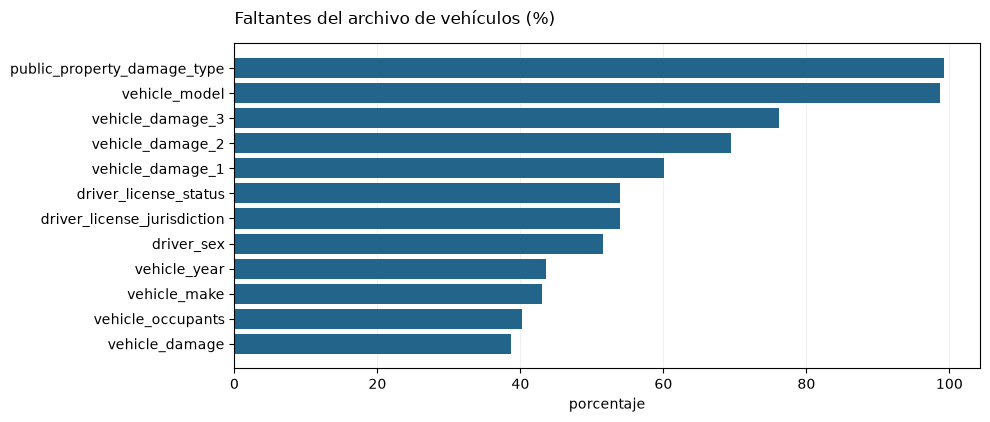

anio,count
2012,198968
2013,404702
2014,409087
2015,434607
2016,457944
2017,464544
2018,465822
2019,426724
2020,231211
2021,227267


In [18]:
reporte = p.calidad(df_crudo)
p.tabla(reporte, 100)
p.guardar_json("02_calidad_vehiculos.json", reporte)
p.barras(sorted(
    reporte, 
    key=lambda r:r["faltantes"], 
    reverse=True
)[:12], 
         "columna", 
         "porcentaje",
         "Faltantes del archivo de vehículos (%)", 
         "calidad_vehiculos.png"
        )

base = df_crudo.withColumn("fecha", p.fecha("crash_date"))
anios = p.cobertura(base)
p.tabla(anios)
p.guardar_json("cobertura_vehiculos.json", anios)
periodo = base.filter(F.year("fecha") == ANIO)

## 4. Duplicados, claves y transformaciones iniciales

Se aplican los mismos filtros usados en el cuaderno de arrestos para eliminar filas con conflictos. Se usa `UNIQUE_ID` para duplicados, nunca `COLLISION_ID` ya que eliminar duplicados por colisión borraría vehículos válidos. Las categorías desconocidas permanecen de esa forma. No se tienen en cuenta año del vehículo, sexo o factores.

In [19]:
limpio, auditoria = p.depurar_identificador(periodo, ["unique_id"])
limpio = (limpio.withColumn(
    "tipo_vehiculo", 
    F.coalesce(
        F.upper(
            p.texto("vehicle_type")
        ), 
        F.lit("SIN DATO")
    )
)
          
    .withColumn(
        "factor_reportado", 
        F.coalesce(
            p.texto("contributing_factor_1"), 
            F.lit("SIN DATO")
        )
    )
          
    .withColumn("anio", F.year("fecha"))
         )

auditoria["sin_collision_id"] = limpio.filter(p.texto("collision_id").isNull()).count()

p.tabla([auditoria])

ruta = p.guardar_json("02_limpieza_vehiculos.json", auditoria)
print("Reporte guardado en:", ruta)

filas_originales,duplicados_exactos,filas_sin_clave,filas_con_clave_conflictiva_excluidas,filas_conservadas,sin_collision_id
465822,0,0,0,465822,0


Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/02_limpieza_vehiculos.json


## 5. Filas y colisiones identificables

Los aquí contados son las colisiones representadas en la tabla de vehículos. Se cuentan vehículos y colisiones por separado.

In [20]:
totales = limpio.agg(F.count("*").alias("filas_vehiculos"), # Cuenta todas las filas conservadas
    F.countDistinct(p.texto("collision_id")).alias("colisiones_identificables")) # Cuenta identificadores de colisión diferentes

p.tabla(p.filas(totales))
ruta = p.guardar_json("unidades_vehiculos.json", p.filas(totales))
print("Reporte guardado en:", ruta)

filas_vehiculos,colisiones_identificables
465822,231542


Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/unidades_vehiculos.json


## 6. Vehículos por colisión registrada

La distribución se agrupa hasta cinco vehículos y una categoría de seis o más. No mide la severidad de los accidentes.

vehiculos_por_colision,count
1,18631
2,196499
3,12936
4,2558
5,618
6 o más,300


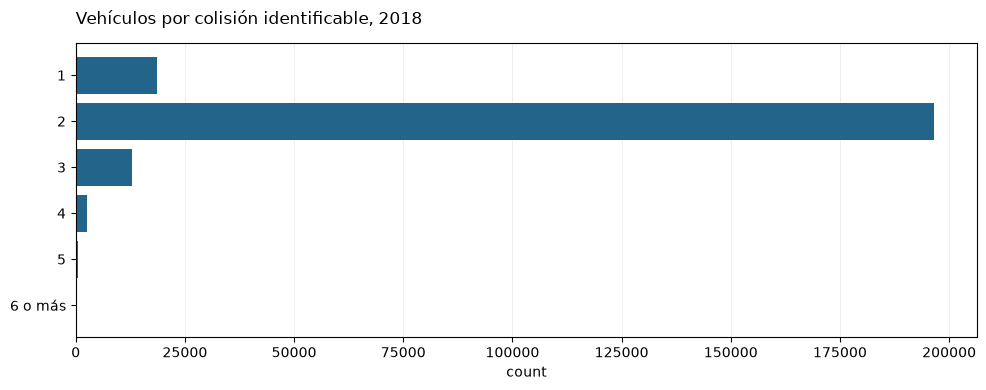

In [21]:
# Se seleccionan las filas con el identificador de colisión. Luego se agrupa las que tienen la misma colisión y se cuenta el registro

por_colision = limpio.filter(p.texto("collision_id").isNotNull()).groupBy("collision_id").count()
distribucion = (por_colision.withColumn("vehiculos_por_colision", F.when(F.col("count") >= 6, "6 o más")
    .otherwise(F.col("count").cast("string"))).groupBy("vehiculos_por_colision").count().orderBy("vehiculos_por_colision"))
datos = p.filas(distribucion)
p.tabla(datos)
p.barras(datos, "vehiculos_por_colision", "count", "Vehículos por colisión identificable, 2018", "vehiculos_por_colision.png")

## 7. Tipos de vehículo

Se muestran las doce etiquetas más frecuentes sin agrupar categorías parecidas. El conteo corresponde a filas de vehículos y no permite inferir riesgo por tipo sin una medida de exposición.

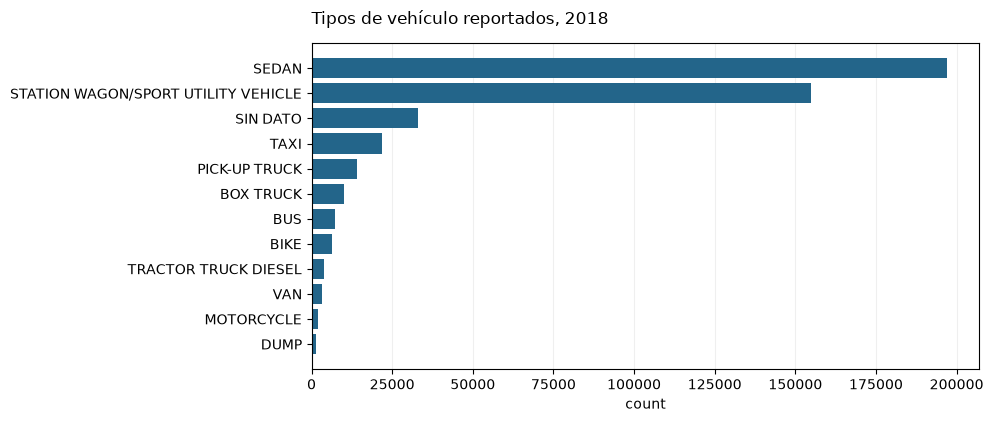

Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/tipos_vehiculo.json


In [22]:
# Se obtienen las etiquetas del vehículo mas frecuente en los registros

tipos = p.filas(
    limpio
        .groupBy("tipo_vehiculo")
        .count()
        .orderBy(F.desc("count"))
        .limit(12)
)

p.barras(
    tipos, 
    "tipo_vehiculo", 
    "count", 
    "Tipos de vehículo reportados, 2018", 
    "tipos_vehiculo.png"
)

ruta = p.guardar_json("tipos_vehiculo.json", tipos)
print("Reporte guardado en:", ruta)

## 8. Disponibilidad del factor reportado

Se segmenta la información por el estado de los factores con el objetivo de saber cuántos registros tienen información en los campos.

estado_factor,count
Factor informado,216775
Ausente,19186
No especificado,229861


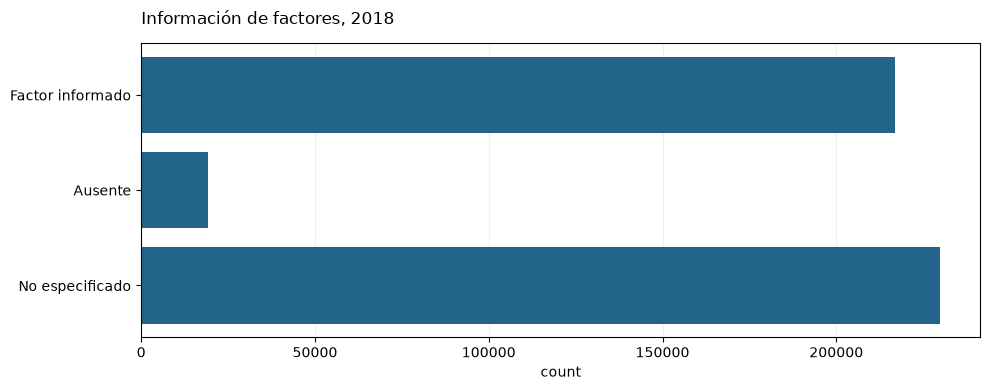

In [23]:
factores = (
    limpio
        .withColumn(
            "estado_factor", 
            F.when(
                F.col("factor_reportado") == "SIN DATO", 
                "Ausente"
            )
            .when(
                F.lower(
                    F.col("factor_reportado")) == "unspecified", 
                "No especificado"
            )
            .otherwise("Factor informado")
        )  
        .groupBy("estado_factor")
        .count()
)

datos = p.filas(factores)
p.tabla(datos)
p.barras(datos, "estado_factor", "count", "Información de factores, 2018", "disponibilidad_factores.png")

## 9. Generar resumen

Se guarda un resumen global con `anio` con el objetivo de que el cuaderno de integración pueda leerlo.

In [24]:
resumen = limpio.groupBy("anio").agg(
    F.count("*").alias("filas_vehiculos"),
    
    F.countDistinct(
        p.texto("collision_id")
    ).alias("colisiones_identificables")
)

p.exportar_resumen(
    resumen, 
    "vehiculos_resumen.json", 
    "Accidentes_Viales_NY.csv", 
    "sin_geografia_ni_victimas",
    {
        "auditoria": auditoria, 
        "cobertura": anios, 
        "columnas_ausentes": [
            "borough", 
            "personas_lesionadas", 
            "personas_fallecidas"
        ]
    }
)

print("Resumen global guardado.")

[Stage 81:====================================>                     (5 + 2) / 8]

Resumen global guardado.


## Cierre

Los JSON y PNG quedan guardados.

In [25]:
# Cierra sesión y limpia cache

spark.catalog.clearCache()
spark.stop()